In [1]:
%cd /content
!git clone https://github.com/amartinsmg/classification-of-medical-images-using-cnn.git
%cd /content/classification-of-medical-images-using-cnn

/content
Cloning into 'classification-of-medical-images-using-cnn'...
remote: Enumerating objects: 994, done.
remote: Counting objects: 100% (382/382), done.
remote: Compressing objects: 100% (263/263), done.
remote: Total 994 (delta 169), reused 300 (delta 114), pack-reused 612 (from 1)
Receiving objects: 100% (994/994), 8.32 MiB | 28.58 MiB/s, done.
Resolving deltas: 100% (495/495), done.
/content/classification-of-medical-images-using-cnn


In [2]:
from google.colab import drive

drive.mount("/content/drive")

BASE_PATH = "/content/drive/MyDrive/classification-of-medical-images-using-cnn/"

Mounted at /content/drive


In [3]:
experiment_names = ["efficientnet-baseline", "efficientnet-no-data-aug",
                  "densenet-baseline", "densenet-no-data-aug",
                  "resnet-baseline", "resnet-no-data-aug"]
COMPARISON_PATH = "comparisons/02-data-aug"
RESULT_PATH = BASE_PATH + "results"
SAVE_DIR = BASE_PATH + COMPARISON_PATH

In [4]:
from src.analyses import load_experiments

experiments = load_experiments(RESULT_PATH, experiment_names)

In [5]:
from src.analyses import metrics_table
from IPython.display import display

metrics = metrics_table(experiments)
display(metrics)

,accuracy-mean,accuracy-std,precision-mean,precision-std,recall-mean,recall-std,f1-score-mean,f1-score-std,specificity-mean,specificity-std,auc-roc-mean,auc-roc-std
experiment,,,,,,,,,,,,
efficientnet-baseline,0.866987,0.022664,0.848382,0.044925,0.964103,0.025726,0.901138,0.013308,0.705128,0.102979,0.961047,0.002615
efficientnet-no-data-aug,0.796474,0.030095,0.756865,0.028928,0.996581,0.003198,0.859976,0.017490,0.462963,0.085494,0.968920,0.002772
densenet-baseline,0.855769,0.019275,0.831175,0.031108,0.968376,0.017433,0.893862,0.010904,0.668091,0.080355,0.956991,0.001435
densenet-no-data-aug,0.819979,0.056270,0.788886,0.064417,0.985470,0.015432,0.874262,0.033387,0.544160,0.174756,0.962950,0.003478
resnet-baseline,0.879808,0.024234,0.885167,0.056200,0.936752,0.042306,0.907570,0.013514,0.784900,0.129684,0.954208,0.005962
resnet-no-data-aug,0.808226,0.018704,0.768948,0.019748,0.992308,0.004187,0.866276,0.010908,0.501425,0.056730,0.963535,0.003811


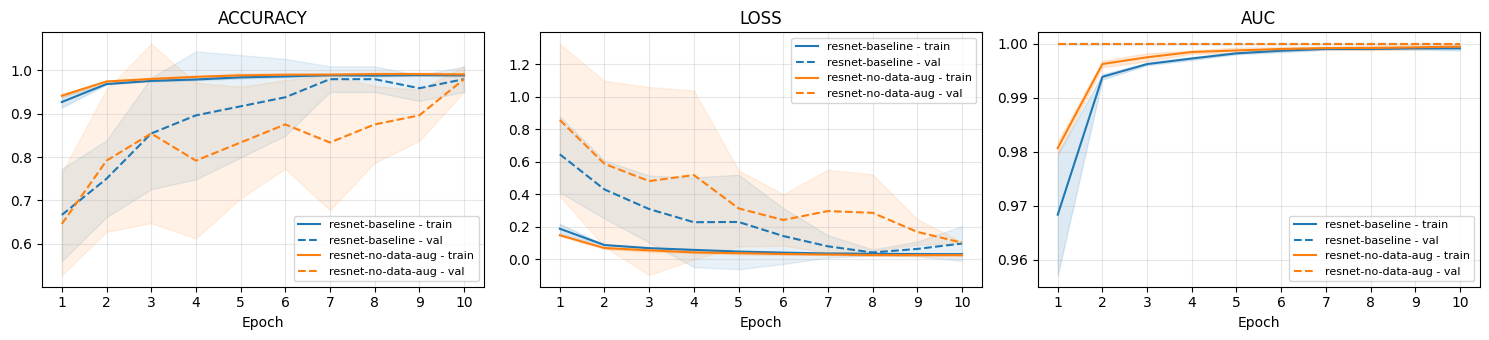

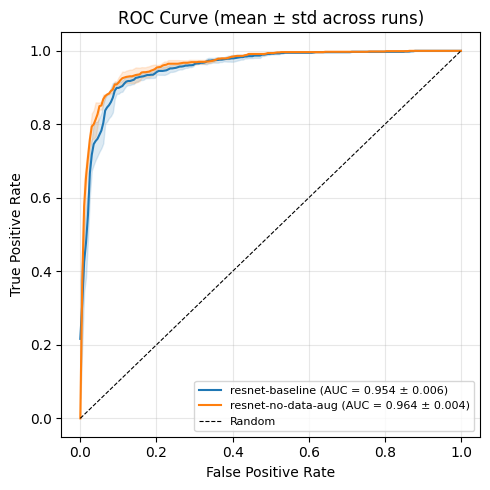

In [6]:
from src.analyses import plot_training_history
from src.analyses import plot_roc_curves
import matplotlib.pyplot as plt

resnet_exps = [exp for exp in experiments if exp.get("name").startswith("resnet")]

fig_history = plot_training_history(resnet_exps)
fig_roc = plot_roc_curves(resnet_exps)

plt.show()

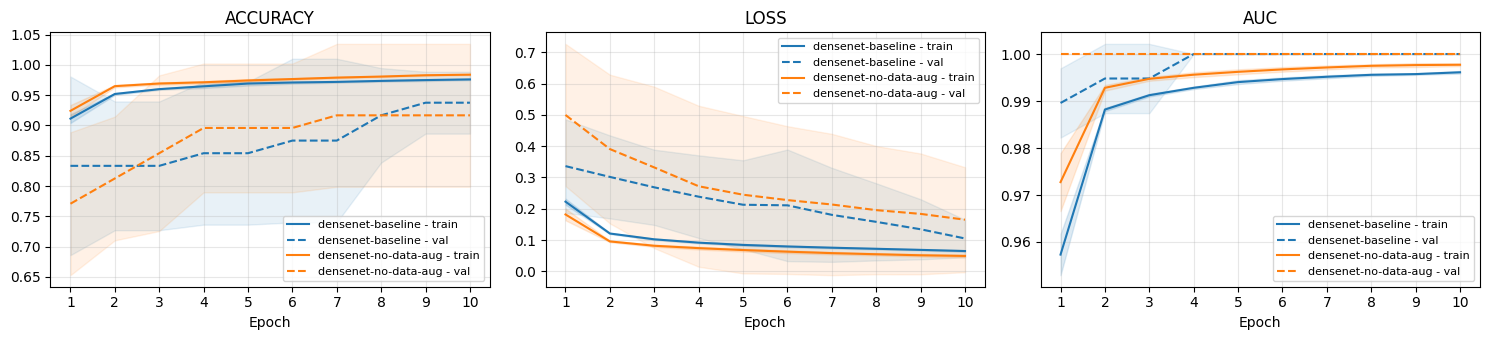

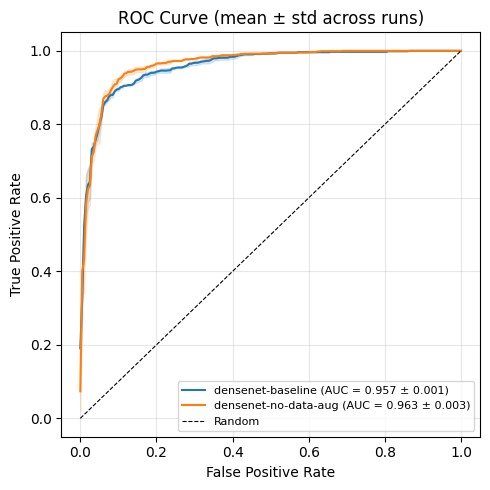

In [7]:
densenet_exps = [exp for exp in experiments if exp.get("name").startswith("densenet")]

fig = plot_training_history(densenet_exps)
fig = plot_roc_curves(densenet_exps)

plt.show()

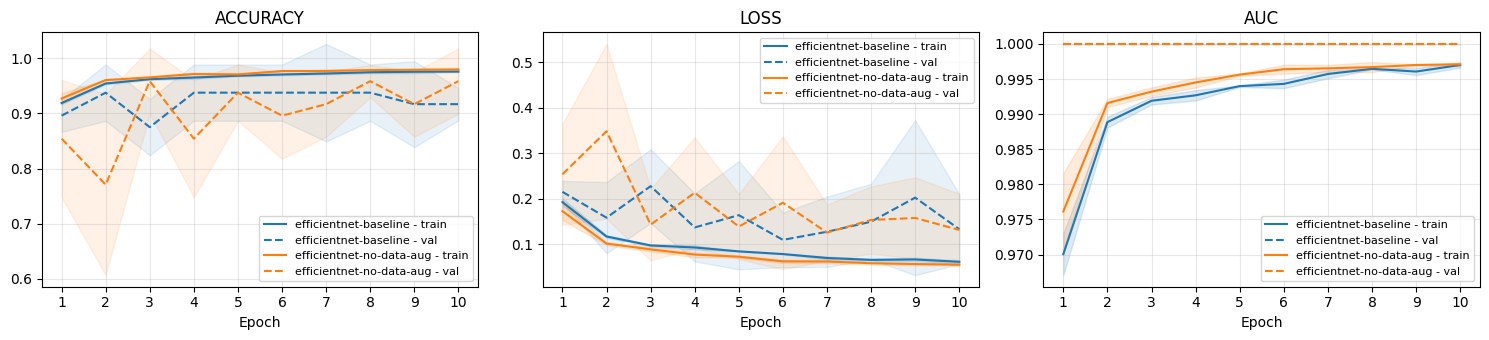

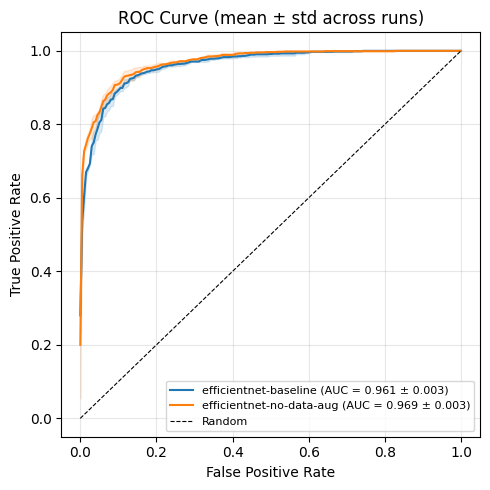

In [8]:
efficientnet_exps = [exp for exp in experiments if exp.get("name").startswith("efficientnet")]

fig = plot_training_history(efficientnet_exps)
fig = plot_roc_curves(efficientnet_exps)

plt.show()

In [11]:
from src.analyses import full_comparison

_ = full_comparison(
  base_result_dir=RESULT_PATH,
  experiment_names=experiment_names,
  show_plot=False,
  save_dir=SAVE_DIR,
  separe_archs=True
)


Results saved in /content/drive/MyDrive/classification-of-medical-images-using-cnn/comparisons/02-data-aug


Faz upload da tabela e dos gráficos das comparações para o DagsHub

In [10]:
%pip install -q dvc dagshub

import dagshub
from google.colab import userdata

dagshub.auth.add_app_token(token=userdata.get("DAGSHUB_TOKEN"))


dagshub.upload_files(
    "amartinsmg/classification-of-medical-images-using-cnn",
    local_path=SAVE_DIR,
    remote_path=COMPARISON_PATH,
    force=True
)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 470.1/470.1 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 273.1/273.1 kB 27.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.2/68.2 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.3/79.3 kB 8.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 451.2/451.2 kB 32.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.0/45.0 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 214.2/214.2 kB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.2/74.2 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.

Accessing as amartinsmg

Output()

Directory upload complete, uploaded 13 files to 
https://dagshub.com/amartinsmg/classification-of-medical-images-using-cnn/src/main/comparisons%2F02-data-aug